# DBSCAN for Malware Feature Analysis

Goal: use DBSCAN to find dense groups of malware-style feature vectors and identify unusual samples as noise.

## Student Information

Name: Bryant Baum

Date: 6/17/2026

Course: CSCE 40103: Intro to AI for Security

In [1]:
# %pip install pandas numpy scikit-learn seaborn matplotlib plotly nbformat scipy

## 1. Load the Dataset

This notebook uses a safe malware-feature dataset.

If `MalwareArtifacts.csv` is available in the same folder, the notebook will use it.
Otherwise, it uses the included synthetic malware-style feature dataset.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_context("notebook")

preferred_file = Path("MalwareArtifacts.csv")
fallback_file = Path("MalwareArtifacts_TextbookStyle_Synthetic.csv")

if preferred_file.exists():
    data_file = preferred_file
elif fallback_file.exists():
    data_file = fallback_file
else:
    data_file = Path("/mnt/data/MalwareArtifacts_TextbookStyle_Synthetic.csv")

df = pd.read_csv(data_file)
print("Loaded:", data_file)
print("Shape:", df.shape)
df.head()

Loaded: MalwareArtifacts_TextbookStyle_Synthetic.csv
Shape: (860, 21)


,sample_id,family,label,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics,FileSizeKB,NumberOfSections,SectionEntropyMean,...,ImportCount,ExportCount,StringCount,URLCount,RegistryStringCount,SuspiciousStringCount,UniqueAPICalls,NetworkAPICount,CryptoAPICount,HasDebugSymbols
0,BCK_0074,persistence_backdoor_like,1,9,0,7,215,1671,5,5.959951,...,189,1,221,2,18,7,183,9,3,0
1,PKD_0185,packed_downloader_like,1,7,0,7,192,398,3,7.284722,...,10,0,141,6,1,8,50,12,8,0
2,BEN_0120,benign_like,0,8,0,7,379,889,5,5.364888,...,83,8,721,0,2,0,98,3,5,0
3,BEN_0208,benign_like,0,8,0,5,273,463,7,5.928565,...,107,10,840,2,0,2,120,3,2,0
4,BEN_0380,benign_like,0,9,1,6,271,495,7,4.847798,...,55,0,786,1,5,2,99,3,1,0


## 2. Inspect the Data

Check columns, missing values, and any available labels.

In [3]:
display(df.info())
display(df.isna().sum().sort_values(ascending=False).head(15))

label_candidates = ["family", "Class", "class", "label", "malware_family", "Name"]
label_col = next((c for c in label_candidates if c in df.columns), None)

if label_col:
    print("Available label column:", label_col)
    display(df[label_col].value_counts())
else:
    print("No label column found. Clustering will be treated as fully unlabeled.")

<class 'pandas.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   sample_id                     860 non-null    str    
 1    family                       860 non-null    str    
 2    label                        860 non-null    int64  
 3    MajorLinkerVersion           860 non-null    int64  
 4    MajorImageVersion            860 non-null    int64  
 5    MajorOperatingSystemVersion  860 non-null    int64  
 6    DllCharacteristics           860 non-null    int64  
 7    FileSizeKB                   860 non-null    int64  
 8    NumberOfSections             860 non-null    int64  
 9    SectionEntropyMean           860 non-null    float64
 10   SectionEntropyMax            860 non-null    float64
 11   ImportCount                  860 non-null    int64  
 12   ExportCount                  860 non-null    int64  
 13   StringCount    

None

sample_id                     0
 ImportCount                  0
 CryptoAPICount               0
 NetworkAPICount              0
 UniqueAPICalls               0
 SuspiciousStringCount        0
 RegistryStringCount          0
 URLCount                     0
 StringCount                  0
 ExportCount                  0
 SectionEntropyMax            0
 family                       0
 SectionEntropyMean           0
 NumberOfSections             0
 FileSizeKB                   0
dtype: int64

No label column found. Clustering will be treated as fully unlabeled.


## 3. Select Numeric Features

Use numeric malware features only.

Remove obvious identifiers and label columns before clustering.

In [4]:
id_like_cols = {"sample_id", "hash", "md5", "sha1", "sha256", "file_name", "filename"}
label_like_cols = {c for c in df.columns if c.lower() in {"family", "class", "label", "malware_family", "name"}}

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in id_like_cols and c not in label_like_cols]

print("Number of selected numeric features:", len(feature_cols))
print(feature_cols)

X = df[feature_cols].copy()
X = X.fillna(X.median(numeric_only=True))

X.head()

Number of selected numeric features: 19
[' label', ' MajorLinkerVersion', ' MajorImageVersion', ' MajorOperatingSystemVersion', ' DllCharacteristics', ' FileSizeKB', ' NumberOfSections', ' SectionEntropyMean', ' SectionEntropyMax ', ' ImportCount', ' ExportCount', ' StringCount', ' URLCount', ' RegistryStringCount', ' SuspiciousStringCount', ' UniqueAPICalls', ' NetworkAPICount', ' CryptoAPICount', ' HasDebugSymbols']


,label,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics,FileSizeKB,NumberOfSections,SectionEntropyMean,SectionEntropyMax,ImportCount,ExportCount,StringCount,URLCount,RegistryStringCount,SuspiciousStringCount,UniqueAPICalls,NetworkAPICount,CryptoAPICount,HasDebugSymbols
0,1,9,0,7,215,1671,5,5.959951,6.499608,189,1,221,2,18,7,183,9,3,0
1,1,7,0,7,192,398,3,7.284722,7.971819,10,0,141,6,1,8,50,12,8,0
2,0,8,0,7,379,889,5,5.364888,6.689225,83,8,721,0,2,0,98,3,5,0
3,0,8,0,5,273,463,7,5.928565,6.988360,107,10,840,2,0,2,120,3,2,0
4,0,9,1,6,271,495,7,4.847798,5.296872,55,0,786,1,5,2,99,3,1,0


## 4. Scale Features

Distance-based clustering needs scaled features.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.head()

,label,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics,FileSizeKB,NumberOfSections,SectionEntropyMean,SectionEntropyMax,ImportCount,ExportCount,StringCount,URLCount,RegistryStringCount,SuspiciousStringCount,UniqueAPICalls,NetworkAPICount,CryptoAPICount,HasDebugSymbols
0,0.977008,0.583328,-1.120132,1.183411,-0.459162,2.043396,0.173261,0.151287,-0.291881,1.916281,-0.648119,-1.086952,-0.370584,2.083813,0.460358,1.215288,0.502856,0.023928,-0.364787
1,0.977008,-0.602635,-1.120132,1.183411,-0.717444,-1.125845,-1.084161,1.552531,1.519395,-1.503563,-0.952035,-1.325155,0.922327,-0.810207,0.686592,-1.038025,1.145436,1.894661,-0.364787
2,-1.023533,-0.009653,-1.120132,1.183411,1.382501,0.096541,0.173261,-0.478126,-0.058593,-0.108878,1.479294,0.401815,-1.017040,-0.639970,-1.123274,-0.224799,-0.782304,0.772221,-0.364787
3,-1.023533,-0.009653,-1.120132,-0.939078,0.192158,-0.964022,1.430683,0.118089,0.309435,0.349649,2.087126,0.756141,-0.370584,-0.980443,-0.670808,0.147929,-0.782304,-0.350219,-0.364787
4,-1.023533,0.583328,-0.077585,0.122166,0.169698,-0.884355,1.430683,-1.025065,-1.771619,-0.643825,-0.952035,0.595354,-0.693812,-0.129261,-0.670808,-0.207857,-0.782304,-0.724365,-0.364787


## 5. Create a 2D View for Plots

PCA is used only for visualization.

The clustering is performed on the scaled feature matrix.

Explained variance ratio: [0.44544457 0.17986707]


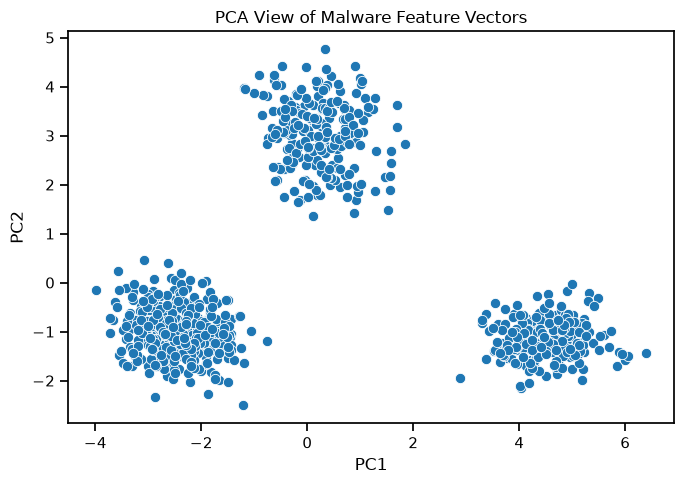

In [6]:
pca = PCA(n_components=2, random_state=40103)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
if label_col:
    pca_df[label_col] = df[label_col].astype(str).values

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
if label_col:
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=label_col, s=55)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
else:
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=55)
plt.title("PCA View of Malware Feature Vectors")
plt.tight_layout()
plt.show()

## 6. Estimate eps with a k-Distance Plot

DBSCAN needs two main parameters:

- `eps`: neighborhood radius
- `min_samples`: minimum points needed to form a dense region

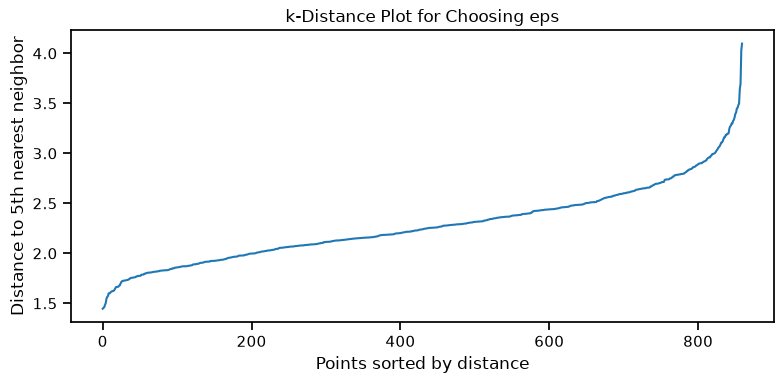

Suggested starting eps values to try:
[2.44  2.488 2.577 2.654 2.787 2.96 ]


In [7]:
from sklearn.neighbors import NearestNeighbors

min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title("k-Distance Plot for Choosing eps")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.tight_layout()
plt.show()

print("Suggested starting eps values to try:")
print(np.round(np.percentile(k_distances, [70, 75, 80, 85, 90, 95]), 3))

## 7. Run DBSCAN

Start with a reasonable eps value from the k-distance plot.

Then tune it based on cluster count, noise count, and interpretation.

In [8]:
from sklearn.cluster import DBSCAN

eps = float(np.percentile(k_distances, 85))
print("Starting eps:", round(eps, 3))
print("min_samples:", min_samples)

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
db_labels = dbscan.fit_predict(X_scaled)

df_db = df.copy()
df_db["dbscan_cluster"] = db_labels

display(df_db["dbscan_cluster"].value_counts().sort_index())

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int((db_labels == -1).sum())

print("Clusters found:", n_clusters)
print("Noise points:", n_noise)

Starting eps: 2.654
min_samples: 5


dbscan_cluster
-1     48
 0    186
 1    210
 2    332
 3     78
 4      6
Name: count, dtype: int64

Clusters found: 5
Noise points: 48


## 8. Compute Silhouette Score

Silhouette score is meaningful only when at least two non-noise clusters exist.

In [9]:
non_noise_mask = db_labels != -1
non_noise_labels = db_labels[non_noise_mask]

if len(set(non_noise_labels)) >= 2:
    score = silhouette_score(X_scaled[non_noise_mask], non_noise_labels)
    print("Silhouette score on non-noise points:", round(score, 4))
else:
    print("Silhouette score not computed: fewer than two non-noise clusters.")

Silhouette score on non-noise points: 0.2737


## 9. Visualize DBSCAN Clusters

Noise points are labeled as `-1`.

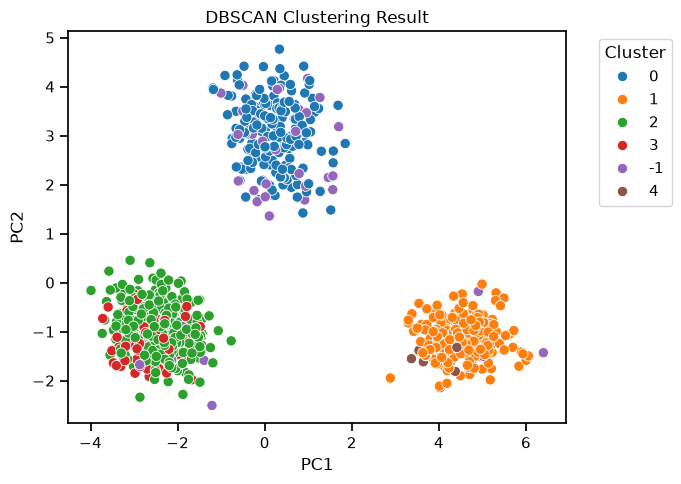

In [10]:
plot_df = pca_df.copy()
plot_df["dbscan_cluster"] = db_labels.astype(str)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="dbscan_cluster", s=55)
plt.title("DBSCAN Clustering Result")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 10. Tune eps and min_samples

Try several parameter values.

Good settings should produce useful clusters without turning everything into noise.

In [11]:
eps_values = np.round(np.percentile(k_distances, [70, 75, 80, 85, 90, 95]), 3)
min_samples_values = [4, 5, 8, 10]

sweep_rows = []

for ms in min_samples_values:
    for ep in eps_values:
        model = DBSCAN(eps=float(ep), min_samples=ms)
        labels = model.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        noise_rate = n_noise / len(labels)

        mask = labels != -1
        if len(set(labels[mask])) >= 2:
            sil = silhouette_score(X_scaled[mask], labels[mask])
        else:
            sil = np.nan

        sweep_rows.append({
            "eps": ep,
            "min_samples": ms,
            "clusters": n_clusters,
            "noise_rate": round(noise_rate, 3),
            "silhouette_non_noise": sil
        })

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df.sort_values(["silhouette_non_noise", "clusters"], ascending=[False, False]).head(15))

,eps,min_samples,clusters,noise_rate,silhouette_non_noise
18,2.440,10,4,0.198,0.358050
12,2.440,8,4,0.178,0.356725
19,2.488,10,4,0.157,0.355637
13,2.488,8,4,0.138,0.353018
20,2.577,10,4,0.103,0.350727
14,2.577,8,4,0.095,0.350248
15,2.654,8,4,0.073,0.349546
21,2.654,10,4,0.077,0.349535
22,2.787,10,4,0.048,0.346706
16,2.787,8,4,0.043,0.345795


## 11. Select a Practical DBSCAN Setting

Choose a setting that gives:

- at least two clusters
- not too much noise
- interpretable cluster profiles

In [12]:
candidates = sweep_df[
    (sweep_df["clusters"] >= 2) &
    (sweep_df["noise_rate"] < 0.40)
].dropna(subset=["silhouette_non_noise"])

if len(candidates) > 0:
    chosen = candidates.sort_values("silhouette_non_noise", ascending=False).iloc[0]
else:
    chosen = sweep_df.sort_values("clusters", ascending=False).iloc[0]

best_eps = float(chosen["eps"])
best_min_samples = int(chosen["min_samples"])

print("Chosen eps:", best_eps)
print("Chosen min_samples:", best_min_samples)

final_dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
final_labels = final_dbscan.fit_predict(X_scaled)

df_db["dbscan_cluster_final"] = final_labels
display(df_db["dbscan_cluster_final"].value_counts().sort_index())

Chosen eps: 2.44
Chosen min_samples: 10


dbscan_cluster_final
-1    170
 0    202
 1    316
 2    107
 3     65
Name: count, dtype: int64

## 12. Inspect Cluster and Noise Profiles

Noise points may be the most interesting samples.

They are unusual under the selected DBSCAN settings.

,label,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics,FileSizeKB,NumberOfSections,SectionEntropyMean,SectionEntropyMax,ImportCount,ExportCount,StringCount,URLCount,RegistryStringCount,SuspiciousStringCount,UniqueAPICalls,NetworkAPICount,CryptoAPICount,HasDebugSymbols
dbscan_cluster_final,,,,,,,,,,,,,,,,,,,
-1,0.77,7.93,1.16,5.76,234.90,1077.68,5.38,5.75,6.77,116.01,3.14,563.70,3.24,10.54,7.48,150.26,7.51,3.46,0.21
0,1.00,6.13,0.38,5.61,153.71,417.38,2.92,7.18,7.84,18.39,0.64,130.71,7.17,4.10,8.07,40.11,12.08,6.04,0.00
1,0.00,9.04,1.47,5.98,329.59,859.48,5.00,5.10,6.11,96.27,4.83,858.47,1.05,1.97,1.08,108.87,2.97,1.13,0.00
2,1.00,8.08,0.84,6.23,221.27,1255.35,6.02,5.84,6.82,152.43,2.20,514.93,2.77,14.99,8.93,193.64,8.16,2.59,0.00
3,0.00,9.02,1.46,6.05,327.00,888.55,5.18,5.19,6.11,94.06,4.17,852.28,1.18,1.65,1.08,106.51,2.94,1.25,1.00


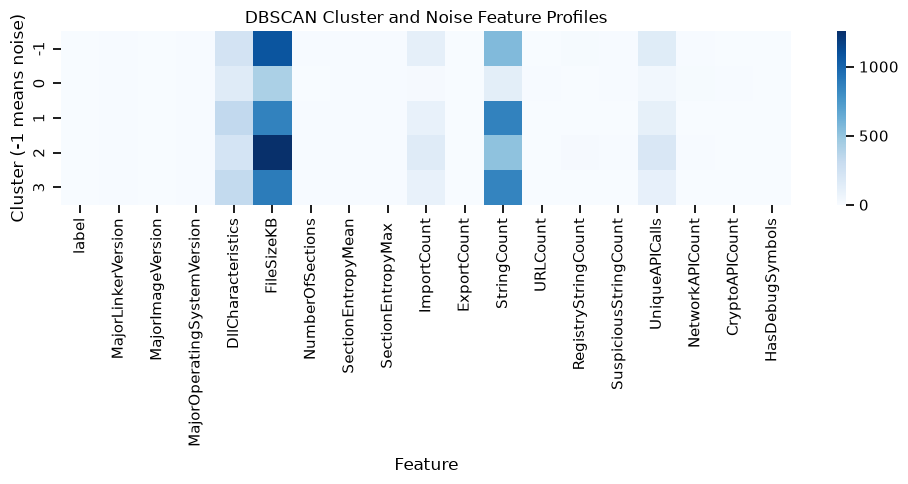

In [13]:
profile = df_db.groupby("dbscan_cluster_final")[feature_cols].mean().round(2)
display(profile)

plt.figure(figsize=(10, 5))
sns.heatmap(profile, cmap="Blues", annot=False)
plt.title("DBSCAN Cluster and Noise Feature Profiles")
plt.xlabel("Feature")
plt.ylabel("Cluster (-1 means noise)")
plt.tight_layout()
plt.show()

## 13. Compare with Known Labels if Available

Use labels only for interpretation.

In [14]:
if label_col:
    display(pd.crosstab(df_db["dbscan_cluster_final"], df_db[label_col], normalize="index").round(3))
else:
    print("No label column available for comparison.")

No label column available for comparison.


## 14. Short Reflection

Answer briefly in markdown:

1. Which eps and min_samples did you choose? 2.64, 10
2. How many clusters did DBSCAN find? 5
3. How many samples were labeled as noise? 1
4. What features describe the largest cluster? FileSizeKB and StringCount
5. Why might noise points matter in malware analysis? Because noise might appear as an outlier, but the problems might occur because of outlier data